# Bank Marketing Subscription Prediction

## End-to-End Imbalanced Classification Study

This project predicts whether a customer will subscribe to a term deposit following a Portuguese bank's direct-marketing campaign. It covers exploratory analysis, leakage-aware feature selection, feature engineering, model benchmarking, stratified cross-validation, hyperparameter tuning, and decision-threshold optimization.

### Project objective

The operational objective is not simply to maximize accuracy. Because subscribers form a small minority of customers, the analysis emphasizes **precision, recall, F1-score, ROC-AUC, and especially PR-AUC**. The final model is intended for pre-call targeting, so `duration` is excluded because it is unavailable until after a call ends.


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Data Loading and Initial Inspection

The enriched UCI Bank Marketing dataset contains customer attributes, campaign information, prior-contact history, macroeconomic indicators, and the binary subscription outcome. The CSV uses semicolons as delimiters.


In [2]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")


In [3]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df = df.rename(columns={"y": "cust_subscribe"})


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset contains **41,188 observations and 21 columns**: 20 predictors and one target. All columns report complete non-null counts, although several categorical variables use the literal value `"unknown"` to represent unavailable information.


### 2.1 Target distribution


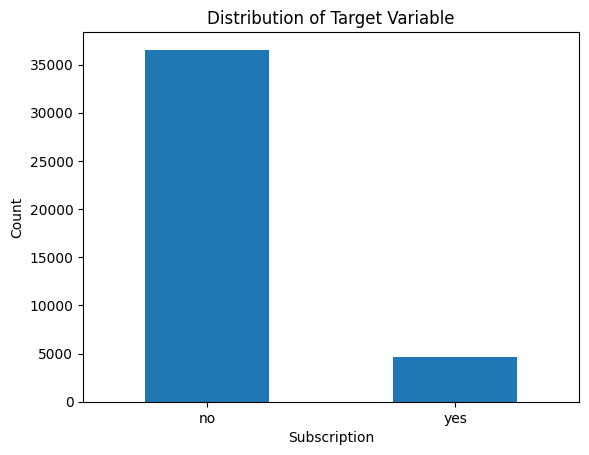

In [6]:
target_counts = df["cust_subscribe"].value_counts()
target_rates = df["cust_subscribe"].value_counts(normalize=True)

print(pd.DataFrame({"count": target_counts, "proportion": target_rates}))

target_counts.plot(kind="bar", color=["#4C78A8", "#F58518"])
plt.title("Distribution of Term-Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Only **4,640 customers (11.27%)** subscribed, while **36,548 (88.73%)** did not. This severe imbalance means that a model predicting `no` for everyone would already achieve roughly 88.7% accuracy; therefore, accuracy cannot be the primary selection metric.


### 2.2 Missing, unknown, and duplicate values


In [7]:
df.isna().sum().to_frame("missing_values")


job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
poutcome          0
cust_subscribe    0
dtype: int64

In [8]:
categorical_feature_names = df.select_dtypes(include="object").columns

unknown_counts = df[categorical_feature_names].eq("unknown").sum()
unknown_counts[unknown_counts > 0].sort_values(ascending=False)


job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
poutcome             0
cust_subscribe       0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(12)

There are no explicit `NaN` values. Six predictors contain `"unknown"`: `job`, `marital`, `education`, `default`, `housing`, and `loan`. These values are retained as explicit categories rather than replaced with guessed values. The 12 duplicate rows represent only about 0.03% of the data and are retained because no customer identifier exists to establish that they are erroneous duplicates.


## 3. Exploratory Data Analysis

The plots below focus on relationships with the subscription target rather than producing a separate univariate chart for every feature.

### 3.1 Numerical features versus subscription


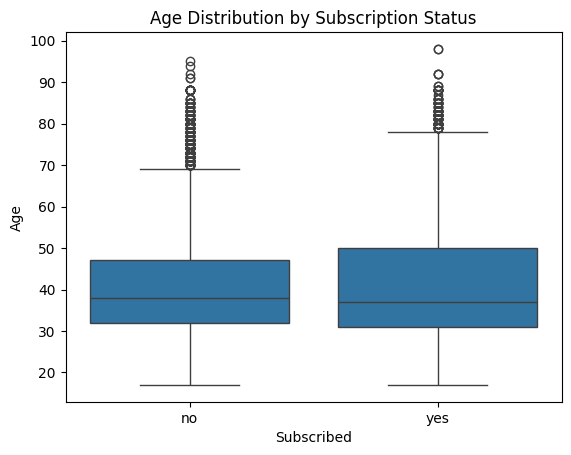

In [10]:
sns.boxplot(data=df, x='cust_subscribe', y='age')
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Age')
plt.show()

Subscriber and non-subscriber age distributions overlap substantially. Median age alone is unlikely to be a strong discriminator.


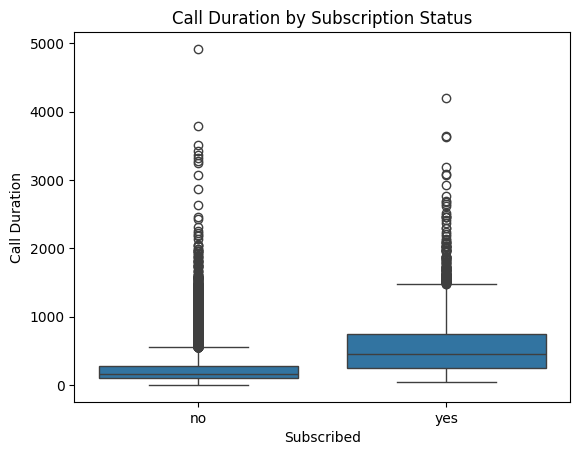

In [11]:
sns.boxplot(data=df, x='cust_subscribe', y='duration')
plt.title('Call Duration by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Call Duration')
plt.show()

Call duration shows strong separation: subscribers had a median duration of approximately **449 seconds**, compared with **163.5 seconds** for non-subscribers. However, duration is only known after the call finishes. It is therefore excluded from the deployable pre-call model despite its predictive strength.


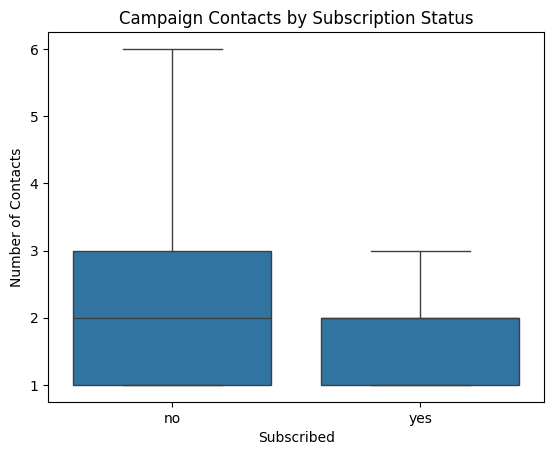

In [12]:
sns.boxplot(data=df, x='cust_subscribe', y='campaign', showfliers=False)
plt.title('Campaign Contacts by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts')
plt.show()

The median number of current-campaign contacts is two in both groups. Subscribers have a lower upper quartile, suggesting that repeated contact does not correspond to a higher conversion rate.


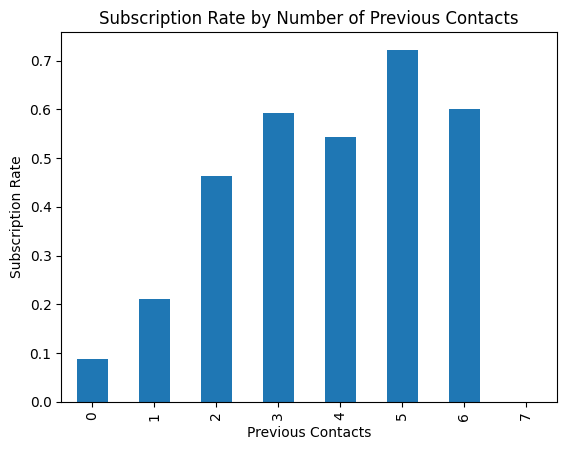

In [13]:
previous_rate = (
    df.groupby('previous')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
)

previous_rate.plot(kind='bar')

plt.title('Subscription Rate by Number of Previous Contacts')
plt.xlabel('Previous Contacts')
plt.ylabel('Subscription Rate')
plt.show()

Subscription rates rise with previous-contact count, but categories above two contacts contain far fewer observations and must be interpreted cautiously.


### 3.2 Categorical subscription rates


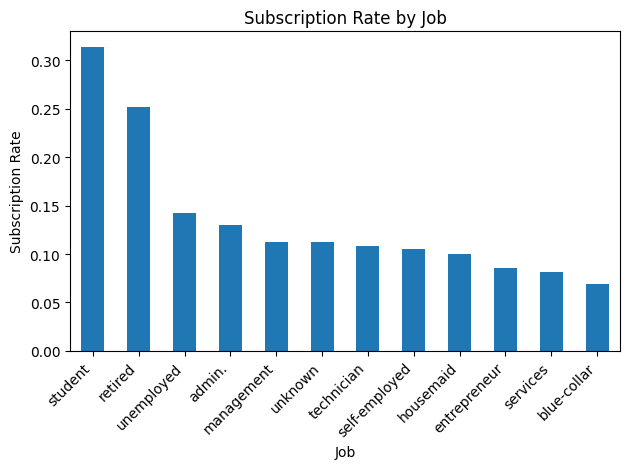

In [14]:
job_rate = (
    df.groupby('job')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values(ascending=False)
)

job_rate.plot(kind='bar')

plt.title('Subscription Rate by Job')
plt.xlabel('Job')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Students have the highest job-level subscription rate (**31.43%**), followed by retired customers (**25.23%**). Blue-collar workers have the lowest rate (**6.89%**).


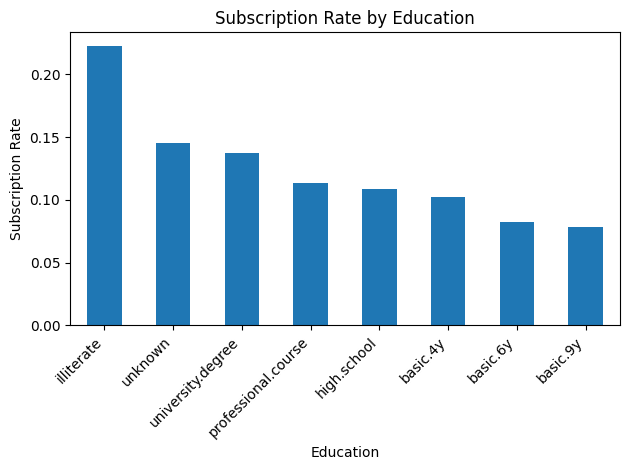

In [15]:
education_rate = (
    df.groupby('education')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values(ascending=False)
)

education_rate.plot(kind='bar')

plt.title('Subscription Rate by Education')
plt.xlabel('Education')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The `illiterate` category has the highest observed rate, but it contains only 18 customers. Among adequately represented groups, university-degree holders have the highest subscription rate.


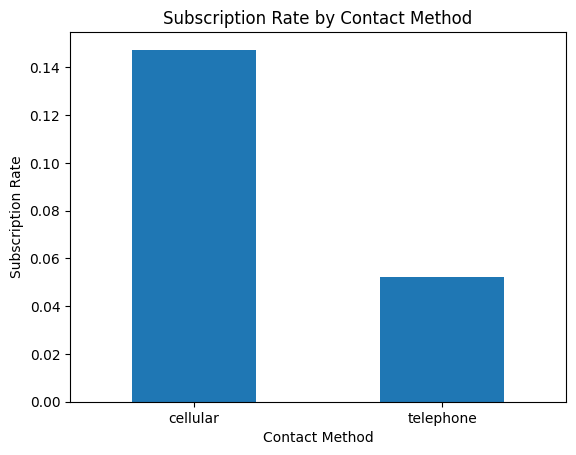

In [16]:
contact_rate = (
    df.groupby('contact')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
)

contact_rate.plot(kind='bar')

plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.show()

Cellular contact is associated with a substantially higher subscription rate (**14.74%**) than telephone contact (**5.23%**).


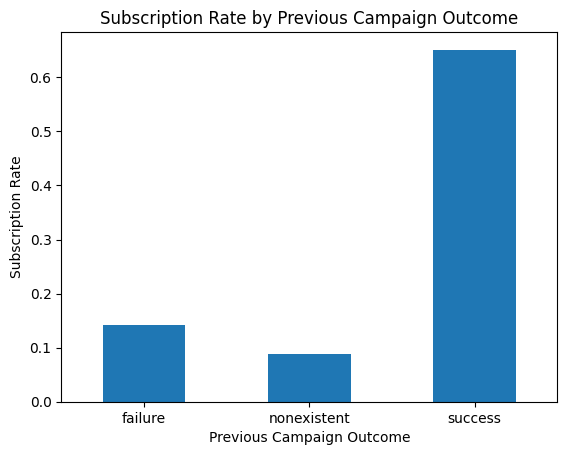

In [17]:
poutcome_rate = (
    df.groupby('poutcome')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
)

poutcome_rate.plot(kind='bar')

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.show()

A successful previous campaign is the strongest categorical signal: **65.11%** of those customers subscribed, compared with **14.23%** after failure and **8.83%** when no previous outcome existed.


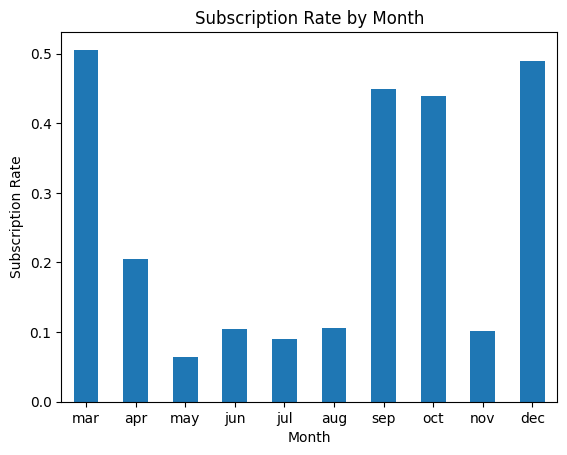

In [18]:
month_order = [
    'mar', 'apr', 'may', 'jun', 'jul',
    'aug', 'sep', 'oct', 'nov', 'dec'
]

month_rate = (
    df.groupby('month')['cust_subscribe']
      .apply(lambda x: (x == 'yes').mean())
      .reindex(month_order)
)

month_rate.plot(kind='bar')

plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate')
plt.xticks(rotation=0)
plt.show()

March, December, September, and October have the highest conversion rates, although these months contain fewer campaign observations than high-volume months such as May.


### 3.3 Economic indicators and correlation


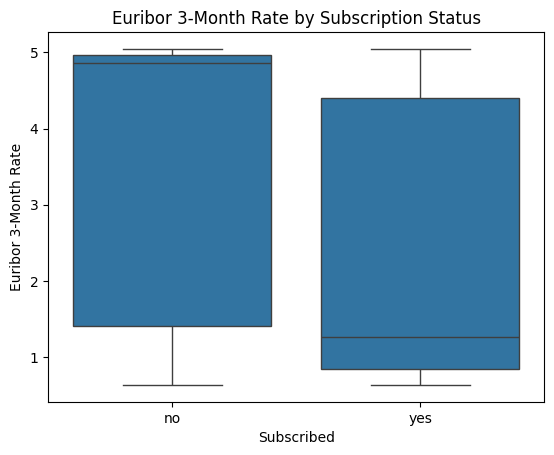

In [19]:
sns.boxplot(data=df, x='cust_subscribe', y='euribor3m')
plt.title('Euribor 3-Month Rate by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Euribor 3-Month Rate')
plt.show()

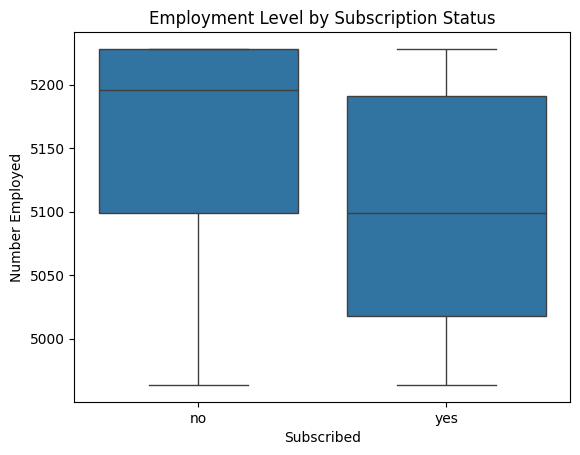

In [20]:
sns.boxplot(data=df, x='cust_subscribe', y='nr.employed')
plt.title('Employment Level by Subscription Status')
plt.xlabel('Subscribed')
plt.ylabel('Number Employed')
plt.show()

Subscribers are associated with lower `euribor3m` and `nr.employed` values, indicating that macroeconomic conditions may influence campaign response.


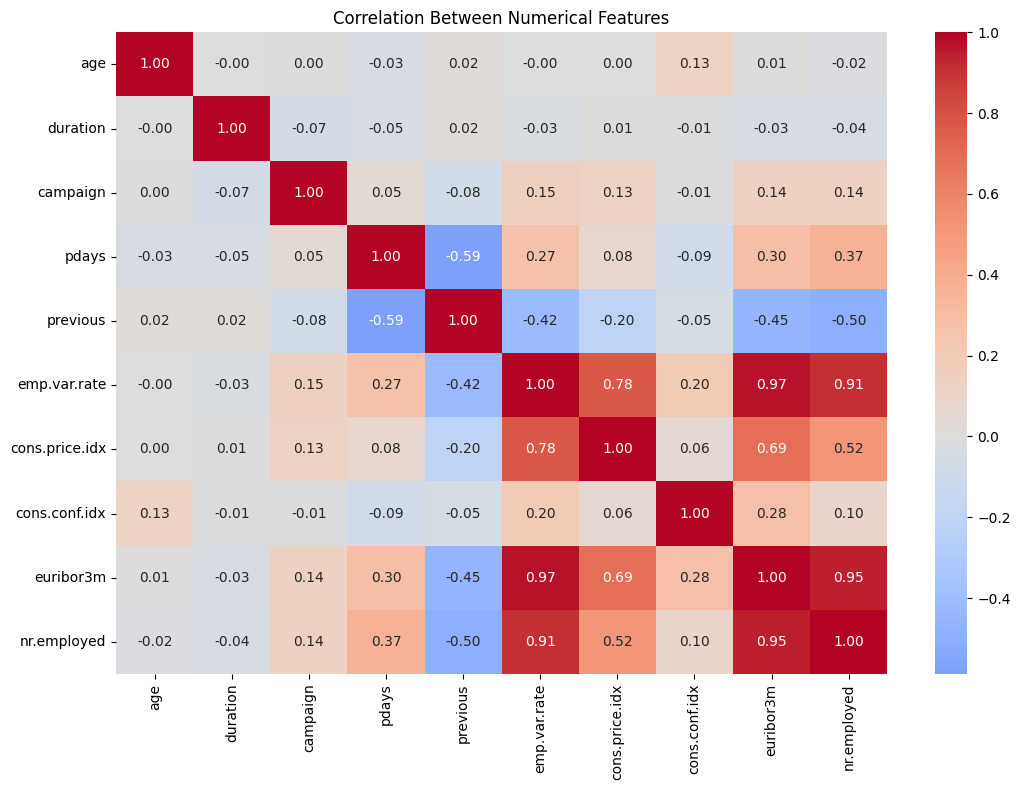

In [21]:
numerical_df = df.select_dtypes(include='number')

plt.figure(figsize=(11, 8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

The economic variables are strongly correlated: `emp.var.rate` and `euribor3m` correlate at approximately **0.97**, while `euribor3m` and `nr.employed` correlate at approximately **0.95**. This multicollinearity is especially relevant for linear-model interpretation, although regularization helps control coefficient instability.


## Key EDA Findings

- The dataset contains **41,188 observations**, **20 input features**, and one binary target variable, `cust_subscribe`. The inputs comprise **10 numerical** and **10 categorical** features.

- The target is strongly imbalanced: **36,548 customers (88.73%)** did not subscribe, while only **4,640 (11.27%)** subscribed. Consequently, accuracy alone would not adequately describe classification performance.

- No explicit null values were detected in any column. However, six categorical features contain `"unknown"` values: `job` (**330**), `marital` (**80**), `education` (**1,731**), `default` (**8,597**), `housing` (**990**), and `loan` (**990**). The issue is most substantial in `default`, where `"unknown"` represents approximately **20.9%** of observations.

- The dataset contains **12 duplicate rows**, representing approximately **0.03%** of all observations. Because no unique customer identifier is available, the notebook cannot establish whether these are erroneous duplicates or distinct customers with identical recorded attributes.

### Numerical Features and Subscription Status

- Subscriber and non-subscriber age distributions overlap considerably. Their median ages are similar—**37 years** for subscribers and **38 years** for non-subscribers—although subscribers have a slightly wider upper-age distribution.

- Call duration shows the clearest separation between the target classes. Subscribers had a median call duration of **449 seconds**, compared with **163.5 seconds** for non-subscribers. The middle 50% of subscriber calls ranged from approximately **253 to 741 seconds**, versus **95 to 279 seconds** for non-subscribers.

- The median number of contacts during the current campaign was **2** for both groups. However, subscribers had a lower upper quartile and mean number of contacts, suggesting that repeated contact was not associated with a higher subscription rate in this dataset.

- Subscription rates generally increased with previous contact history: customers with no previous contacts subscribed at **8.83%**, compared with **21.20%** for one previous contact and **46.42%** for two. Rates above two contacts were higher still, but these categories contained much smaller samples and should therefore be interpreted cautiously.

- Subscribers were associated with lower economic-indicator values. Median `euribor3m` was **1.266** among subscribers versus **4.857** among non-subscribers, while median `nr.employed` was **5,099.1** versus **5,195.8**, respectively.

### Categorical Features and Subscription Rates

- Subscription rates differed substantially by occupation. **Students had the highest rate at 31.43%**, followed by **retired customers at 25.23%**. The lowest rates occurred among **blue-collar workers (6.89%)**, customers in **services (8.14%)**, and **entrepreneurs (8.52%)**.

- The `illiterate` education category had the highest observed subscription rate at **22.22%**, but it contained only **18 customers**, so this result is not robust. Among well-represented education groups, customers with a **university degree** had the highest rate at **13.72%**.

- Customers contacted by **cellular phone** subscribed at **14.74%**, compared with only **5.23%** for those contacted by telephone.

- Previous campaign outcome was strongly associated with the target. Customers whose previous campaign outcome was **successful** subscribed at **65.11%**, compared with **14.23%** after a previous failure and **8.83%** when no previous outcome existed.

- Subscription rates varied markedly by month. They were highest in **March (50.55%)**, **December (48.90%)**, **September (44.91%)**, and **October (43.87%)**, and lowest in **May (6.43%)**. Some high-rate months contain substantially fewer observations than the major campaign months, so the rates should be considered alongside category sizes.

### Correlation Analysis

- The economic variables exhibit strong multicollinearity. The strongest correlations are between `emp.var.rate` and `euribor3m` (**0.97**), `euribor3m` and `nr.employed` (**0.95**), and `emp.var.rate` and `nr.employed` (**0.91**).

- `emp.var.rate` is also strongly correlated with `cons.price.idx` (**0.77**), while `cons.price.idx` and `euribor3m` have a correlation of **0.69**.

- `pdays` and `previous` have a moderate negative correlation of **−0.59**, consistent with their representation of previous campaign-contact history.

### Overall

The EDA identifies several potentially informative relationships with subscription status, particularly **call duration, previous campaign success, prior contact history, contact method, campaign month, and economic conditions**. It also highlights three important modelling considerations: **severe target imbalance, non-random `"unknown"` categories, and substantial multicollinearity among the economic indicators**. Observed relationships are associative and should not be interpreted as causal.


## 4. Train/Test Split and Feature Engineering

The target is separated before preprocessing, and a stratified 80/20 split preserves the approximately 89:11 class distribution. The test set is not used to fit transformations or tune hyperparameters.

`duration` is removed because it is unavailable at pre-call prediction time. The sentinel `pdays = 999` is decomposed into two interpretable features:

- `previously_contacted`: whether any prior contact occurred;
- `days_since_previous_contact`: elapsed days when contacted, otherwise zero.

The indicator distinguishes a genuine zero-day interval from the zero placeholder used for customers with no previous contact.


In [22]:
X = df.drop(["cust_subscribe", "duration"], axis = 1)
y = df["cust_subscribe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


In [23]:
X_train["previously_contacted"] = (X_train["pdays"] != 999).astype(int)
X_test["previously_contacted"] = (X_test["pdays"] != 999).astype(int)

X_train["days_since_previous_contact"] = X_train["pdays"].replace(999, 0)
X_test["days_since_previous_contact"] = X_test["pdays"].replace(999, 0)

X_train = X_train.drop(columns="pdays")
X_test = X_test.drop(columns="pdays")

## 5. Preprocessing

Categorical variables are one-hot encoded because their labels have no natural numeric order. The literal `"unknown"` remains a learnable category. `handle_unknown="ignore"` also prevents errors if a genuinely unseen category appears later.

Numerical features are standardized using means and standard deviations learned from the training set only. The fitted encoder and scaler are then applied unchanged to the test set.


In [24]:
categorical_columns_names = X_train.select_dtypes(include = "object").columns
continous_columns_names = X_train.select_dtypes(exclude = "object").columns

In [25]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop=None,
    sparse_output = False
)

one_hot_encoder.fit(X_train[categorical_columns_names])

X_train_categorical_encoded = one_hot_encoder.transform(X_train[categorical_columns_names])
X_test_categorical_encoded = one_hot_encoder.transform(X_test[categorical_columns_names])


In [26]:
scaler = StandardScaler()

scaler.fit(X_train[continous_columns_names])

X_train_continous_scaled = scaler.transform(X_train[continous_columns_names])
X_test_continous_scaled = scaler.transform(X_test[continous_columns_names])

In [27]:
encoded_column_names = one_hot_encoder.get_feature_names_out(
    categorical_columns_names
)

X_train_categorical_df = pd.DataFrame(
    X_train_categorical_encoded,
    columns = encoded_column_names,
    index = X_train.index
)

X_test_categorical_df = pd.DataFrame(
    X_test_categorical_encoded,
    columns = encoded_column_names,
    index = X_test.index

)

In [28]:
X_train_continuous_df = pd.DataFrame(
    X_train_continous_scaled,
    columns=continous_columns_names,
    index=X_train.index
)

X_test_continuous_df = pd.DataFrame(
    X_test_continous_scaled,
    columns=continous_columns_names,
    index=X_test.index
)

In [29]:
X_train = pd.concat(
    [X_train_continuous_df, X_train_categorical_df],
    axis = 1
)
X_test = pd.concat(
    [X_test_continuous_df, X_test_categorical_df],
    axis = 1
)

The final design matrices contain **63 features**: 53 one-hot categorical indicators and 10 numerical features. Both splits have identical feature names and ordering.

> **Methodological note:** these transformations are correctly fitted without using the test set. For fully fold-isolated production training, the encoder, scaler, and estimator should be wrapped in a scikit-learn `Pipeline` so transformations are refitted within each cross-validation fold. The present notebook records the completed experiment transparently and treats cross-validation comparisons as model-selection evidence rather than a replacement for the held-out test evaluation.


## 6. Initial Model Benchmarks

The models are first evaluated without hyperparameter tuning. The dummy classifier establishes the majority-class baseline.

### 6.1 Majority-class baseline


In [30]:
baseline = DummyClassifier(strategy = "most_frequent")

baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

print(confusion_matrix(y_test, baseline_predictions))

print(
    classification_report(
        y_test,
        baseline_predictions,
        zero_division=0
    )
)

[[7310    0]
 [ 928    0]]
              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



The baseline predicts `no` for every customer. Its high accuracy reflects class imbalance, while subscriber precision, recall, and F1 are all zero.


### 6.2 Logistic Regression


In [31]:
logistic_regression = LogisticRegression(random_state = 42)

logistic_regression.fit(X_train, y_train)
logistic_predictions = logistic_regression.predict(X_test)

print(confusion_matrix(y_test, logistic_predictions))

print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

[[7218   92]
 [ 725  203]]
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      7310
         yes       0.69      0.22      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



Standard Logistic Regression is conservative: it achieves high accuracy and precision but identifies only a small fraction of subscribers. Class weighting is assessed formally during cross-validation.


### 6.3 Decision Tree


In [32]:
decision_tree = DecisionTreeClassifier(random_state = 42)
decision_tree.fit(X_train, y_train)

tree_train_predictions = decision_tree.predict(X_train)
tree_test_predictions = decision_tree.predict(X_test)

print(
    "Training accuracy:",
    accuracy_score(y_train, tree_train_predictions)
)

print(
    "Test accuracy:",
    accuracy_score(y_test, tree_test_predictions)
)

print(confusion_matrix(y_test, tree_test_predictions))

print(
    classification_report(
        y_test,
        tree_test_predictions,
        zero_division=0
    )
)

Training accuracy: 0.9954172989377845
Test accuracy: 0.8417091527069677
[[6625  685]
 [ 619  309]]
              precision    recall  f1-score   support

          no       0.91      0.91      0.91      7310
         yes       0.31      0.33      0.32       928

    accuracy                           0.84      8238
   macro avg       0.61      0.62      0.62      8238
weighted avg       0.85      0.84      0.84      8238



The unrestricted Decision Tree substantially overfit the training data, achieving 99.54% training accuracy but only 83.99% test accuracy. Its subscriber-class F1-score was 0.32, indicating weak minority-class performance. The large generalization gap suggests that the tree requires pruning through constraints such as maximum depth and minimum leaf size.

### 6.4 Random Forest


In [33]:
rf = RandomForestClassifier(n_estimators = 300, random_state = 42)

rf.fit(X_train, y_train)

rf_train_predictions = rf.predict(X_train)
rf_test_predictions = rf.predict(X_test)

print(
    "Training accuracy:",
    accuracy_score(y_train, rf_train_predictions)
)

print(
    "Test accuracy:",
    accuracy_score(y_test, rf_test_predictions)
)

print(confusion_matrix(y_test, rf_test_predictions))

print(
    classification_report(
        y_test,
        rf_test_predictions,
        zero_division=0
    )
)

Training accuracy: 0.9954172989377845
Test accuracy: 0.8970623937848993
[[7114  196]
 [ 652  276]]
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7310
         yes       0.58      0.30      0.39       928

    accuracy                           0.90      8238
   macro avg       0.75      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



The Random Forest improves test performance over a single tree, but its near-perfect training accuracy and weaker minority-class recall indicate continued overfitting.


In [34]:
y_train_binary = y_train.map({"no": 0, "yes": 1})
y_test_binary = y_test.map({"no": 0, "yes": 1})


### 6.5 XGBoost


In [35]:
xgb = XGBClassifier(random_state = 42, n_jobs = -1)

xgb.fit(X_train, y_train_binary)

xgb_train_predictions = xgb.predict(X_train)
xgb_test_predictions = xgb.predict(X_test)

print(
    "Training accuracy:",
    accuracy_score(y_train_binary, xgb_train_predictions)
)

print(
    "Test accuracy:",
    accuracy_score(y_test_binary, xgb_test_predictions)
)

print(confusion_matrix(y_test_binary, xgb_test_predictions))

print(
    classification_report(
        y_test_binary,
        xgb_test_predictions,
        target_names=["no", "yes"],
        zero_division=0
    )
)



Training accuracy: 0.9299848254931715
Test accuracy: 0.9004612770089827
[[7144  166]
 [ 654  274]]
              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7310
         yes       0.62      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.77      0.64      0.67      8238
weighted avg       0.88      0.90      0.88      8238



In [36]:
xgb_probabilities = xgb.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test_binary, xgb_probabilities)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_binary,
        xgb_probabilities
    )
)

ROC-AUC: 0.8007158356526252
PR-AUC: 0.46201947460193254


The untuned XGBoost model achieved a ROC-AUC of 0.801 and a PR-AUC of 0.462. Its PR-AUC substantially exceeded the approximately 0.113 minority-class prevalence, indicating meaningful ability to identify potential subscribers. However, at the default 0.5 classification threshold, subscriber recall remained low. This suggests that subsequent threshold tuning may improve the precision–recall trade-off.

## 7. Stratified Cross-Validation

Five-fold stratified cross-validation compares all model families using identical splits. PR-AUC is emphasized because it directly reflects minority-class ranking quality and has a random reference value equal to the subscriber prevalence (~0.113).


In [37]:
models = {
    "Dummy": DummyClassifier(
        strategy="prior"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Balanced Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_jobs=1
    )
}

In [38]:
cv = StratifiedKFold(n_splits = 5, shuffle= True, random_state = 42)


In [39]:
scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [40]:
cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train_binary,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,

        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV PR-AUC": scores["test_pr_auc"].mean(),

        "Train F1": scores["train_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

In [41]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV PR-AUC",
    ascending=False
)

cv_results_df.round(3)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC,Train F1,F1 Std
1,Logistic Regression,0.900,0.658,0.230,0.340,0.789,0.449,0.342,0.014
2,Balanced Logistic Regression,0.827,0.350,0.622,0.448,0.790,0.444,0.452,0.004
5,XGBoost,0.897,0.590,0.280,0.380,0.780,0.433,0.597,0.016
4,Random Forest,0.892,0.543,0.278,0.367,0.773,0.415,0.983,0.009
3,Decision Tree,0.841,0.311,0.337,0.323,0.622,0.181,0.983,0.013
0,Dummy,0.887,0.000,0.000,0.000,0.500,0.113,0.000,0.000


Cross-validation identifies Logistic Regression as the strongest and most stable model family before tuning. Standard Logistic Regression achieves the highest initial PR-AUC (**0.449**), while balanced Logistic Regression produces the highest subscriber recall (**0.622**) and F1 (**0.448**). XGBoost is competitive but shows a larger train-validation gap. Random Forest and Decision Tree substantially overfit and are not selected for tuning.


## 8. Hyperparameter Tuning

Logistic Regression and XGBoost are tuned with `GridSearchCV`. Every configuration is evaluated with the same stratified folds, and the search refits the configuration with the highest cross-validated PR-AUC.

### 8.1 Logistic Regression


In [42]:
logistic_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

logistic_search = GridSearchCV(
    estimator=LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ),
    param_grid=logistic_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [43]:
logistic_search.fit(X_train, y_train_binary);


In [44]:
print("Best parameters:")
print(logistic_search.best_params_)

print("\nBest CV PR-AUC:")
print(logistic_search.best_score_)

Best parameters:
{'C': 1, 'class_weight': None, 'penalty': 'l1'}

Best CV PR-AUC:
0.44915973727362013


In [45]:
logistic_grid_results = pd.DataFrame(
    logistic_search.cv_results_
)

logistic_grid_results[
    [
        "param_C",
        "param_penalty",
        "param_class_weight",
        "mean_train_pr_auc",
        "mean_test_pr_auc",
        "mean_test_f1",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_roc_auc"
    ]
].sort_values(
    "mean_test_pr_auc",
    ascending=False
).head(10)

,param_C,param_penalty,param_class_weight,mean_train_pr_auc,mean_test_pr_auc,mean_test_f1,mean_test_precision,mean_test_recall,mean_test_roc_auc
12,1.0,l1,None,0.455089,0.449160,0.339978,0.661012,0.228991,0.789019
13,1.0,l2,None,0.455116,0.449113,0.339262,0.657819,0.228721,0.788950
16,10.0,l1,None,0.455290,0.448917,0.338930,0.657525,0.228452,0.788816
20,100.0,l1,None,0.455299,0.448911,0.338467,0.656334,0.228182,0.788800
21,100.0,l2,None,0.455306,0.448906,0.338803,0.656586,0.228452,0.788803
17,10.0,l2,None,0.455303,0.448893,0.338930,0.657525,0.228452,0.788807
8,0.1,l1,None,0.451943,0.448570,0.333810,0.674622,0.221986,0.789596
9,0.1,l2,None,0.453347,0.448216,0.334165,0.662357,0.223604,0.789107
10,0.1,l1,balanced,0.447812,0.443989,0.446365,0.348315,0.621499,0.789815
19,10.0,l2,balanced,0.448773,0.443593,0.448685,0.350889,0.622307,0.789581


In [46]:
best_logistic_model = logistic_search.best_estimator_

### 8.2 XGBoost


In [47]:
negative_count = (y_train_binary == 0).sum()
positive_count = (y_train_binary == 1).sum()

class_ratio = negative_count / positive_count

print(class_ratio)

7.876616379310345


In [48]:
from xgboost import XGBClassifier

xgb_grid = {
    "n_estimators": [150, 300],
    "learning_rate": [0.03, 0.1],
    "max_depth": [3, 5],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1, class_ratio]
}

In [49]:
xgb_search = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1
    ),
    param_grid=xgb_grid,
    scoring=scoring,
    refit="pr_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [50]:
xgb_search.fit(X_train, y_train_binary);


In [51]:
print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV PR-AUC:")
print(xgb_search.best_score_)

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 150, 'scale_pos_weight': 1, 'subsample': 0.8}

Best CV PR-AUC:
0.4701397672491369


In [52]:
xgb_grid_results = pd.DataFrame(
    xgb_search.cv_results_
)

xgb_grid_results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "param_min_child_weight",
        "param_subsample",
        "param_colsample_bytree",
        "param_scale_pos_weight",
        "mean_train_pr_auc",
        "mean_test_pr_auc",
        "mean_test_f1",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_roc_auc"
    ]
].sort_values(
    "mean_test_pr_auc",
    ascending=False
).head(10)

,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree,param_scale_pos_weight,mean_train_pr_auc,mean_test_pr_auc,mean_test_f1,mean_test_precision,mean_test_recall,mean_test_roc_auc
24,150,0.03,5,5,0.8,0.8,1.000000,0.523520,0.470140,0.349152,0.667756,0.236802,0.798776
89,150,0.03,5,5,1.0,1.0,1.000000,0.523242,0.469296,0.349821,0.667798,0.237339,0.798255
88,150,0.03,5,5,0.8,1.0,1.000000,0.526232,0.469269,0.350221,0.666858,0.237878,0.798265
26,150,0.03,5,5,0.8,0.8,7.876616,0.521660,0.468914,0.465202,0.368024,0.632544,0.798997
16,150,0.03,5,1,0.8,0.8,1.000000,0.535790,0.468663,0.347683,0.666546,0.235456,0.798194
28,300,0.03,5,5,0.8,0.8,1.000000,0.553734,0.468559,0.359300,0.646854,0.249195,0.799066
90,150,0.03,5,5,0.8,1.0,7.876616,0.524726,0.468380,0.466112,0.369851,0.630387,0.798320
25,150,0.03,5,5,1.0,0.8,1.000000,0.522402,0.468187,0.349012,0.664945,0.237068,0.798086
92,300,0.03,5,5,0.8,1.0,1.000000,0.557366,0.468007,0.363456,0.651906,0.252426,0.797537
80,150,0.03,5,1,0.8,1.0,1.000000,0.539554,0.468005,0.350099,0.660457,0.238686,0.797635


In [53]:
best_xgb_model = xgb_search.best_estimator_

In [54]:
print(
    "Logistic CV PR-AUC:",
    logistic_search.best_score_
)

print(
    "XGBoost CV PR-AUC:",
    xgb_search.best_score_
)

Logistic CV PR-AUC: 0.44915973727362013
XGBoost CV PR-AUC: 0.4701397672491369


In [55]:
best_index = xgb_search.best_index_

print("Best parameters:")
print(xgb_search.best_params_)

print(
    "Train PR-AUC:",
    xgb_search.cv_results_["mean_train_pr_auc"][best_index]
)

print(
    "Validation PR-AUC:",
    xgb_search.cv_results_["mean_test_pr_auc"][best_index]
)

print(
    "Validation precision:",
    xgb_search.cv_results_["mean_test_precision"][best_index]
)

print(
    "Validation recall:",
    xgb_search.cv_results_["mean_test_recall"][best_index]
)

print(
    "Validation F1:",
    xgb_search.cv_results_["mean_test_f1"][best_index]
)

print(
    "Validation ROC-AUC:",
    xgb_search.cv_results_["mean_test_roc_auc"][best_index]
)

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 150, 'scale_pos_weight': 1, 'subsample': 0.8}
Train PR-AUC: 0.5235198632766416
Validation PR-AUC: 0.4701397672491369
Validation precision: 0.6677557944326983
Validation recall: 0.23680242914098523
Validation F1: 0.3491517698568787
Validation ROC-AUC: 0.7987757052173812


Tuned XGBoost achieves the best cross-validated PR-AUC (**0.470**), exceeding tuned Logistic Regression (**0.449**). Its train PR-AUC of **0.524** versus validation PR-AUC of **0.470** indicates moderate, manageable overfitting. The selected configuration uses a low learning rate, row and feature subsampling, and increased child-weight regularization. `scale_pos_weight=1` shows that explicit class weighting did not maximize PR-AUC for this model.


## 9. Out-of-Fold Threshold Selection

The default probability threshold of 0.5 favors precision but yields low subscriber recall. To choose a more useful operating point without consulting the test labels, out-of-fold probabilities are generated from the training data. The selected threshold maximizes subscriber F1 across those predictions.


In [56]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

best_xgb_model = xgb_search.best_estimator_

oof_probabilities = cross_val_predict(
    best_xgb_model,
    X_train,
    y_train_binary,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [57]:
precision, recall, thresholds = precision_recall_curve(
    y_train_binary,
    oof_probabilities
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_threshold_index = np.argmax(f1_scores)

best_threshold = thresholds[best_threshold_index]
best_precision = precision[best_threshold_index]
best_recall = recall[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]

print("Selected threshold:", best_threshold)
print("OOF precision:", best_precision)
print("OOF recall:", best_recall)
print("OOF F1:", best_f1)

Selected threshold: 0.20143715
OOF precision: 0.4468399915451279
OOF recall: 0.5695043103448276
OOF F1: 0.5007698684808717


The selected threshold intentionally accepts more false-positive contacts in exchange for detecting a much larger share of genuine subscribers. Because it is chosen from out-of-fold training predictions, the test labels do not influence this decision.


## 10. Final Holdout Evaluation

The tuned XGBoost estimator is already refitted on all training data by `GridSearchCV`. Its test probabilities are converted to class predictions using the training-selected threshold.


In [58]:
test_probabilities = best_xgb_model.predict_proba(X_test)[:, 1]

final_predictions = (
    test_probabilities >= best_threshold
).astype(int)

In [59]:
print(confusion_matrix(y_test_binary, final_predictions))

print(
    classification_report(
        y_test_binary,
        final_predictions,
        target_names=["no", "yes"],
        zero_division=0
    )
)

print(
    "Final ROC-AUC:",
    roc_auc_score(y_test_binary, test_probabilities)
)

print(
    "Final PR-AUC:",
    average_precision_score(
        y_test_binary,
        test_probabilities
    )
)

[[6700  610]
 [ 376  552]]
              precision    recall  f1-score   support

          no       0.95      0.92      0.93      7310
         yes       0.48      0.59      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238

Final ROC-AUC: 0.8162164931128827
Final PR-AUC: 0.48881701695735863


## 11. Final Results and Business Interpretation

The final model achieves:

- **ROC-AUC:** 0.816
- **PR-AUC:** 0.489
- **Subscriber precision:** 0.48
- **Subscriber recall:** 0.59
- **Subscriber F1:** 0.53
- **Correctly identified subscribers:** 552 of 928
- **Missed subscribers:** 376
- **Non-subscribers incorrectly flagged:** 610

Threshold tuning nearly doubles subscriber recall relative to the untuned XGBoost model's default-threshold result (approximately 0.30 to 0.59) and raises subscriber F1 from approximately 0.40 to 0.53. Accuracy declines to 0.88 because the model deliberately predicts more positive cases. This is a sensible trade-off when finding potential subscribers is more valuable than maximizing majority-class accuracy.

## 12. Limitations and Next Steps

- The analysis establishes association, not causation; campaign timing and contact method may reflect operational targeting decisions.
- `"unknown"` is retained as a category. Future work could test whether explicit missingness indicators or alternative treatments improve generalization.
- Several economic indicators are highly correlated, which complicates direct interpretation of individual linear coefficients.
- The selected threshold maximizes F1. A production threshold should instead reflect the bank's actual cost per contact and value per subscription.
- Preprocessing should be encapsulated in a single production pipeline, versioned alongside the trained model.
- Model interpretation can be extended with permutation importance or SHAP values, followed by fairness and calibration checks.

## Conclusion

The project demonstrates why accuracy alone is inadequate for imbalanced campaign-response prediction. A tuned XGBoost model, paired with an out-of-fold decision threshold, provides the strongest overall precision-recall trade-off while remaining deployable before a marketing call begins.
